In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = pd.read_csv("train_data.csv")
valid_df = pd.read_csv("valid_data.csv")
test_df  = pd.read_csv("test_data.csv")

In [26]:
label_recommendation = (
    train_df[["Label", "Recommendation"]]
    .drop_duplicates()
    .set_index("Label")["Recommendation"]
    .to_dict()
)

In [27]:
print(train_df.columns)

Index(['Image_Name', 'Label', 'N', 'P', 'K', 'ph', 'soil_moisture',
       'temperature', 'humidity', 'rainfall', 'sunlight_exposure',
       'Recommendation'],
      dtype='object')


In [28]:
features = [
    "N",
    "P",
    "K",
    "ph",
    "soil_moisture",
    "temperature",
    "humidity",
    "rainfall",
    "sunlight_exposure"
]

target = "Label"

In [29]:
X_train = train_df[features]
y_train = train_df[target]

X_valid = valid_df[features]
y_valid = valid_df[target]

X_test = test_df[features]
y_test = test_df[target]


In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test  = scaler.transform(X_test)

# save scaler
joblib.dump(scaler,"rf_scaler.pkl")

['rf_scaler.pkl']

In [31]:
print(train_df["Label"].value_counts())

Label
Early Deficiency       273
Critical Deficiency    269
Healthy                269
Name: count, dtype: int64


In [32]:
rf_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=3,
    min_samples_split=100,
    min_samples_leaf=50,
    max_features="sqrt",
    bootstrap=True,
    max_samples=0.5,
    class_weight="balanced",
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=3, max_samples=0.5,
                       min_samples_leaf=50, min_samples_split=100,
                       n_estimators=30, random_state=42)

In [33]:
train_pred = rf_model.predict(X_train)

print("\nTrain Accuracy:")
print(accuracy_score(y_train, train_pred))

print("\nTrain Classification Report:")
print(classification_report(y_train, train_pred))


Train Accuracy:
0.9864364981504316

Train Classification Report:
                     precision    recall  f1-score   support

Critical Deficiency       0.98      0.99      0.98       269
   Early Deficiency       0.99      0.97      0.98       273
            Healthy       0.99      1.00      1.00       269

           accuracy                           0.99       811
          macro avg       0.99      0.99      0.99       811
       weighted avg       0.99      0.99      0.99       811



In [34]:
valid_pred = rf_model.predict(X_valid)

print("\nValidation Accuracy:")
print(accuracy_score(y_valid,valid_pred))

print("\nClassification Report:")
print(classification_report(y_valid,valid_pred))



Validation Accuracy:
0.9698275862068966

Classification Report:
                     precision    recall  f1-score   support

Critical Deficiency       0.99      0.97      0.98        74
   Early Deficiency       0.96      0.95      0.95        74
            Healthy       0.97      0.99      0.98        84

           accuracy                           0.97       232
          macro avg       0.97      0.97      0.97       232
       weighted avg       0.97      0.97      0.97       232



In [35]:
test_pred = rf_model.predict(X_test)

print("\nTest Accuracy:")
print(accuracy_score(y_test,test_pred))

print("\nTest Classification Report:")
print(classification_report(y_test,test_pred))


Test Accuracy:
0.9655172413793104

Test Classification Report:
                     precision    recall  f1-score   support

Critical Deficiency       0.95      1.00      0.97        35
   Early Deficiency       1.00      0.89      0.94        38
            Healthy       0.96      1.00      0.98        43

           accuracy                           0.97       116
          macro avg       0.97      0.96      0.96       116
       weighted avg       0.97      0.97      0.96       116



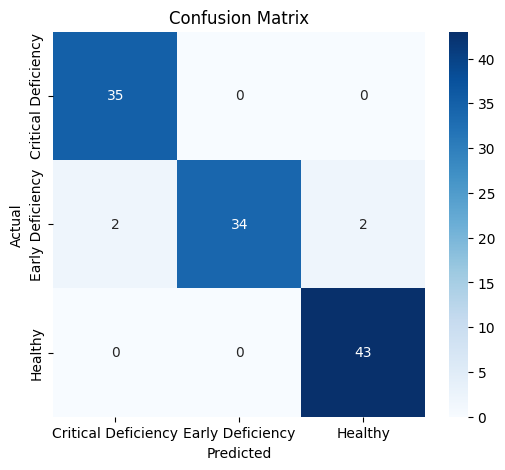

In [36]:
cm = confusion_matrix(y_test,test_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()



Feature Importance:
             Feature  Importance
5        temperature    0.202433
7           rainfall    0.198923
6           humidity    0.192290
8  sunlight_exposure    0.125051
0                  N    0.113200
4      soil_moisture    0.088545
1                  P    0.056822
3                 ph    0.019985
2                  K    0.002752


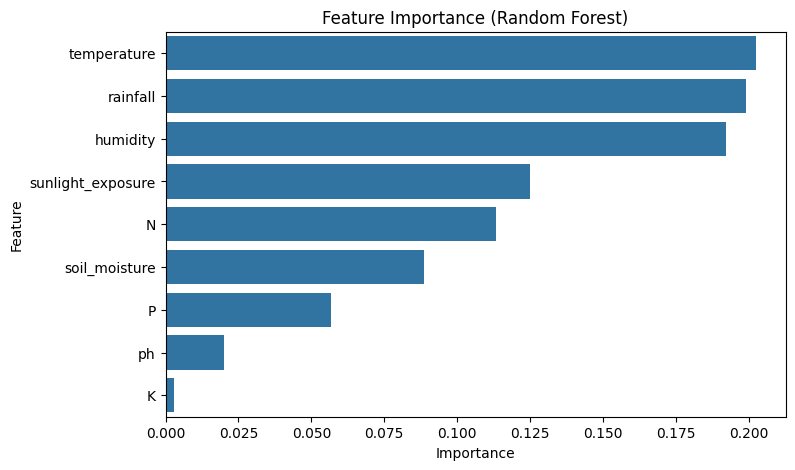

In [37]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature":features,
    "Importance":importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance (Random Forest)")
plt.show()


In [38]:
joblib.dump(rf_model,"rf_metadata_model.pkl")

print("\nModel saved as rf_metadata_model.pkl")


Model saved as rf_metadata_model.pkl


In [ ]:
sample_data = {
    "N": 52,
    "P":58,
    "K": 40,
    "ph": .6,
    "soil_moisture": 18.0,
    "temperature": 16.0,
    "humidity": 25.0,
    "rainfall": 20.0,
    "sunlight_exposure": 5.0
}
sample_df = pd.DataFrame([sample_data])

sample_scaled = scaler.transform(sample_df)

prediction = rf_model.predict(sample_scaled)
probabilities = rf_model.predict_proba(sample_scaled)

confidence = np.max(probabilities) * 100

predicted_label = prediction[0]

recommendation = label_recommendation.get(predicted_label, "No recommendation available.")

print("Predicted Deficiency:", predicted_label)
print(f"Confidence Score: {confidence:.2f}%")
print("Recommendation:", recommendation)

Predicted Deficiency: Critical Deficiency
Confidence Score: 62.08%
Recommendation: URGENT: Immediate corrective actions required. Nitrogen is relatively low. Apply nitrogen-rich fertilizers like urea or compost. Potassium is insufficient. Add potash fertilizers to improve plant strength. Soil moisture is low. Ensure regular irrigation and consider mulching.
